DataFrame shape: (6898, 7)


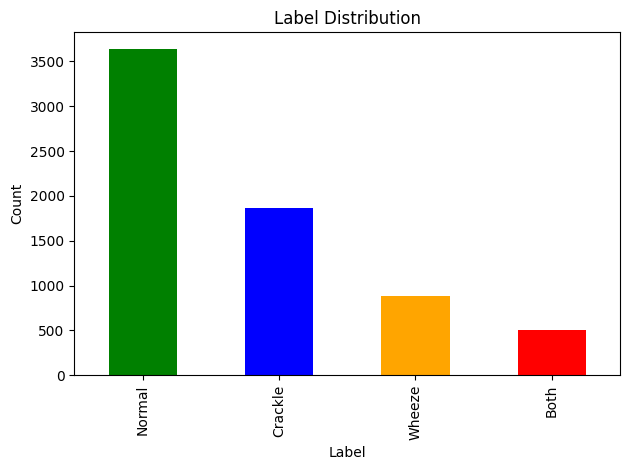

Saved DataFrame to C:\Users\Kruthi K Shetty\data-science\data\cycles_df.csv


: 

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

data_dir = r'C:\Users\Kruthi K Shetty\data-science\data\audio_and_txt_files'

records = []

# 1. Loop through all .txt files in the folder
txt_files = glob.glob(os.path.join(data_dir, '*.txt'))

for filepath in txt_files:
    filename = os.path.basename(filepath)
    patient_id = filename.split('_')[0]
    
    # 2. Parse each row
    try:
        df_txt = pd.read_csv(filepath, sep='\\s+', names=['start_time', 'end_time', 'crackle', 'wheeze'])
        for _, row in df_txt.iterrows():
            crackle_present = int(row['crackle'])
            wheeze_present = int(row['wheeze'])
            
            # 3. Create a label column
            if crackle_present == 0 and wheeze_present == 0:
                label = 'Normal'
            elif crackle_present == 1 and wheeze_present == 0:
                label = 'Crackle'
            elif crackle_present == 0 and wheeze_present == 1:
                label = 'Wheeze'
            else:
                label = 'Both'
                
            records.append({
                'patient_id': int(patient_id),
                'filename': filename,
                'cycle_start': row['start_time'],
                'cycle_end': row['end_time'],
                'crackle_present': crackle_present,
                'wheeze_present': wheeze_present,
                'label': label
            })
    except Exception as e:
        print(f"Error processing {filename}: {e}")

# 4. Build a pandas DataFrame
cycles_df = pd.DataFrame(records)

# Also load patient_diagnosis.csv if it exists in the folder and merge it
diagnosis_path = os.path.join(data_dir, 'patient_diagnosis.csv')
if not os.path.exists(diagnosis_path):
    diagnosis_path = os.path.join(os.path.dirname(data_dir), 'patient_diagnosis.csv')

if os.path.exists(diagnosis_path):
    try:
        diagnosis_df = pd.read_csv(diagnosis_path, names=['patient_id', 'diagnosis'])
        diagnosis_df['patient_id'] = pd.to_numeric(diagnosis_df['patient_id'], errors='coerce')
        cycles_df['patient_id'] = pd.to_numeric(cycles_df['patient_id'], errors='coerce')
        cycles_df = cycles_df.merge(diagnosis_df, on='patient_id', how='left')
        print("Merged patient_diagnosis.csv")
    except Exception as e:
        print(f"Error reading diagnosis file: {e}")

# 5. Print the shape and show a bar chart of label distribution
print("DataFrame shape:", cycles_df.shape)
cycles_df['label'].value_counts().plot(kind='bar', title='Label Distribution', xlabel='Label', ylabel='Count', color=['green', 'blue', 'orange', 'red'])
plt.tight_layout()
plt.show()

# 6. Save the DataFrame as data/cycles_df.csv
output_dir = r'C:\Users\Kruthi K Shetty\data-science\data'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'cycles_df.csv')
cycles_df.to_csv(output_path, index=False)
print(f"Saved DataFrame to {output_path}")


In [3]:
pip install librosa pandas matplotlib seaborn

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached numba-0.65.0-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp311-cp311-win_amd64.whl.metadata (5.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached msgpack-1.1.2-cp311-cp311-win_amd64.whl.metadata (8.4 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.